# **BILIS (Legislative Bills Intelligence System)**
## Transforming Raw House Bills into Scannable, NLP-Powered Insights.
-------------------------


As a fourth-year Computer Science student specializing in Data Science, I have spent my college years learning how to build pipelines, clean messy datasets, analyze data, and train models. But during my On-the-Job Training (OJT), as I watched the recent, intriguing developments unfold within the Philippine Senate, it hit me, I am not as aware in the developments of the my country as much as I think. And that same sentiment goes for my fellow youth.

My generation of Filipino youth is incredibly tech-savvy. We can navigate complex interfaces, digest digital content at lightning speed, stay constantly connected, and have the power to access any information we can. Yet, when it comes to political awareness and tracking actual legislative progress, there is a massive disconnect. Most youths aren't politically aware, and are only interested in the drama. A lot of my peers aren’t politically indifferent; they are just overwhelmed.

**The problem is that, they do not know who to vote, and vote whoever is "popular" with the masses.**

The barriers to entry are frustratingly high:
- Legislative bills, panel reports, and statutory updates are naturally dense, written in formal legal jargon, and span dozens of pages, making them incredibly intimidating for casual reading.
- Keeping track of dynamic updates, identifying which lawmakers authored specific bills, and tracing a piece of legislation's history requires navigating outdated or non-intuitive government portals.
- Traditional methods of disseminating political information simply do not align with the consumption habits of modern youth, who favor concise and short digestible content.
- The youth will be joining the voting population, them not being aware will lead to major lapses in political voting turnaround. 

I wanted to use my skills to build a bridge over that gap. This project was born out of a desire to create a piece of Civic Technology that speaks our language and help the Filipino youth be more political aware.

By engineering an automated pipeline that leverages multi-threaded data aggregation and Natural Language Processing (NLP), my goal is to democratize legislative data. By transforming raw, unstructured government datasets into clean, searchable inventories and concise text summaries, this tool translates dense political maneuvers into accessible, objective insights. 

Ultimately, I want to empower my fellow tech-savvy youth, and give them the clarity we need to foster informed civic engagement, bridge the political awareness gap, and hold our leadership accountable.

-------------------------

## Background
To understand why a data pipeline for tracking bills is so critical, it is essential to look at the structural foundation of our democracy. The Philippine government is modeled after a presidential system and is divided into three co-equal branches: the Executive, the Legislative, and the Judicial. While they operate independently under a system of checks and balances, they are deeply bound by a single, common thread: the law.

- **Executive Branch** (led by the President and the Cabinet) is tasked with enforcing and executing the laws of the land.
- **Judicial Branch** (headed by the Supreme Court) interprets those laws and settles legal controversies.
- **Legislative Branch** (vested in the bicameral Congress of the Philippines) holds the sole authority to create, alter, and repeal them.

As a Data Science student looking at this system, Congress is essentially the core engine where raw societal needs are encoded into structural data—what we call Bills.


### The Structure of Congress


Our Legislative branch is split into two separate chambers, both of which must agree on a piece of legislation before it can ever become a reality:

**The Senate (Upper House**): Composed of 24 Senators elected at large by the entire country, representing national interests.

**The House of Representatives (Lower House**): Composed of district representatives and party-list nominees who champion localized and sector-specific concerns.



### How a Bill Becomes a Law


The journey of a bill from a simple policy idea to an enacted Republic Act (RA) is a highly bureaucratic, multi-stage process. Understanding this pipeline highlights exactly why tracking it manually is so exhausting for the average citizen.

The standard lifecycle involves several critical phases:
- **Introduction and First Reading**: A Senator or Representative files a bill. It is assigned a unique tracking number (like the HBN or house bill numbers I am parsing in my code). During the First Reading, only its title and number are read on the floor, and it is immediately referred to an appropriate Committee (e.g., Committee on Health, Committee on Education).
- **The Committee Public Hearing**: This is where the real work happens. The committee reviews the bill, invites experts, holds public consultations, and debates its merits. They can amend it, consolidate it with similar bills, kill it entirely, or approve it via a Committee Report to be sent to the whole chamber.
- **Second Reading (The Crucible)**: The bill is brought before the entire plenary floor. The sponsorship speech is delivered, followed by intense floor debates, interpellation (questioning), and individual amendments. This is where a bill is heavily scrutinized. Once debates close, the chamber votes on it via a viva voce (voice) or counted vote.
- **Third Reading**: If passed on the second reading, printed copies of the final version are distributed to the members days in advance. No more amendments are allowed. A final, nominal vote is cast where members register their "Yes," "No," or "Abstain."
- **Bicameral Conference Committee (The Matchmaking)**: Since a bill must be passed by both houses in identical language, a special joint committee is often formed to reconcile conflicting provisions between the Senate version and the House version. The resulting "Bicameral Report" must be ratified by both chambers.
- **Presidential Enactment**: Once an identical bill passes both houses, it is enrolled and sent to the Malacañang Palace for the President's signature. The President has three choices:
    - Sign it: It immediately becomes a Republic Act.
    - Veto it: The President rejects it and sends it back with objections (which Congress can override with a 2/3 majority vote in both houses).
    - Lapse into Law: If the President takes no action within 30 days of receiving it, the bill automatically becomes law as if it had been signed.
    - Note: The new law officially takes effect 15 days after its publication in the Official Gazette or in newspapers of general circulation.



### The Challenge in the System


There are thousands of bills moving through different stages simultaneously across two different chambers. They are being amended, substituted, delayed, or fast-tracked.

For an ordinary "Gen-Z" youth, following this process is difficult and at times, overwhelming. Trying to find out what is actually happening in government creates an overwhelming data fragmentation problem. Valuable information is buried inside lengthy PDF committee reports, complex congressional journals, and dense legal terminology.

By mapping out this exact legislative workflow into a clean data engineering model, my project seeks to turn this complex civic pipeline into structured, transparent, and instantly readable knowledge.

---

## Data Sourcing
To build a reliable data pipeline for tracking Philippine legislation, I am integrating and cross-referencing two distinct data sources from the **Open Congress API**, and **BetterGov.PH** (a civic technology organization dedicated to making public data accessible and actionable).


### 1. Source A: The Open Congress API (Metadata Extraction)



* **Endpoint:** `https://open-congress-api.bettergov.ph/api/`
* **Role in Pipeline:** Metadata Retrieval

The Open Congress API serves as our live relational engine. From the `/documents` endpoint, I fetch structured metadata files containing critical legal contexts for House Bills (HB) across multiple congressional terms (specifically tracking the 13th to the 20th Congress).

The key features pulled from this API include:

* **Congress Term:** The specific legislative period (e.g., `18`, `19`, `20`).
* **Document Number / Name:** The unique, official alphanumeric bill identifier (e.g., `HBN-06098`).
* **Authors:** Nested structural data containing the names, suffixes, and initials of the legislators sponsoring or co-authoring the bill.
* **Scope & Dates:** Regional or national targeting scopes along with formal filing timestamps where available.

### 2. Source B: Hugging Face Repository (Full-Text Content Extraction)



* **Dataset Identifier:** `bettergovph/raw-philippine-data` (specifically the `documents` split)
* **Role in Pipeline:** Heavy Text Retrieval

While the API provides excellent categorical records, reading and processing tens of thousands of long, multi-page legal documents via live HTTP network endpoints is highly inefficient, and most documents are simply scanned as images. To solve the problem of processing heavy text at scale, I pull the raw text file records directly from BetterGov.PH's open-source repository hosted on Hugging Face.

This specific text dataset holds the literal transcribed text blocks of over 60,000 legislative items. The features I pull from this split are:

* **ID:** The unique matching index token string (e.g., `hb-18-6098`).
* **Content:** The complete, unedited full-text transcription of the legal bill document.



### Limitations of the Project

The data source will be discussed below, however, there are limitations as to what can be used. Due to the data source's limitations of the BetterGov HuggingFace dataset only containing House Bills and Congress data from the 13th-20th Congress, this project will only make use of House Bills under the 13th up to the 20th Congress.

---


## Data Collection

This section implements a data scraping pipeline designed to harvest House Bills (HB) across the 13th to the 20th Philippine Congress using the Open Congress API.

Because fetching thousands of documents sequentially over HTTP is incredibly slow, this script leverages Python’s **concurrent.futures** to download multiple pages in parallel, while protecting itself against network instability with automated connection retries and exponential backoff.


#### Imports and Configurations


First, we import the necessary libraries. We utilize requests for network operations, pandas for structural data manipulation, and concurrency utilities for multi-threading. We also configure our BASE_URL API template and set a pagination constraint of LIMIT = 20 items per request.

In [ ]:
import requests
import pandas as pd
from datasets import load_dataset
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

BASE_URL = "https://open-congress-api.bettergov.ph/api/congresses/{}/documents"
LIMIT = 20


### Open Congress API

#### Creating a Resilient HTTP Session


Network operations are prone to occasional drops, 502 Bad Gateway, or 503 Service Unavailable errors.

To prevent our script from crashing mid-execution, **get_session()** builds a customized requests.Session() object configured with an automated Retry Strategy:
- It attempts a failed call up to **5 times**. 
- It introduces a **backoff_factor** to pause incrementally before retrying.
- It targets specific server failure codes **(500, 502, 503, 504)** to avoid overloading the host.

In [ ]:
def get_session():
    session = requests.Session()

    retry = Retry(
        total=5,
        backoff_factor=0.5,
        status_forcelist=[500, 502, 503, 504],
        allowed_methods=["GET"]
    )

    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    return session


session = get_session()


#### Fetching an Individual Page with Exponential Backoff


The **fetch_page** function handles pulling a single, specific slice (or "page") of data defined by an offset.

This function wraps the call in a loop if the session's default retry strategy fails due to rate limits or heavier connection anomalies. It implements a manual **Exponential Backoff Mechanism (wait = 2 ^ attempt)**. If an error is caught, it waits 1s, then 2s, then 4s, and so on, before trying again. If it fails entirely after 5 manual attempts, it returns an empty list [] to preserve pipeline execution.

In [ ]:
def fetch_page(congress_id, offset):
    url = BASE_URL.format(congress_id)

    for attempt in range(5):
        try:
            r = session.get(
                url,
                params={"type": "HB", "limit": LIMIT, "offset": offset},
                timeout=30
            )
            r.raise_for_status()
            return r.json()["data"]

        except Exception as e:
            wait = 2 ** attempt
            print(f"Retrying {congress_id} offset {offset} in {wait}s...")
            time.sleep(wait)

    return []


#### Multi-Threaded Congress Extraction and Flattening


The **fetch_congress** function serves to collect the current congress data to gather the documents within it.
1. It fires an initial request (offset=0) to inspect the total volume of bills available (data["pagination"]["total"]). It computes a list of all required offsets.
2. It spins up a ThreadPoolExecutor using up to 5 parallel worker threads. Each thread executes a fetch_page task asynchronously to collect 5 batches at a time.
3. As tasks finish (as_completed), it logs live tracking markers and extends the results list.
4. Finally, it uses pd.json_normalize(all_data) to automatically flatten any nested JSON dictionaries into a clean, tabular Pandas DataFrame.

In [ ]:

def fetch_congress(congress_id):
    print(f"\nCongress {congress_id}")

    # get total
    r = session.get(
        BASE_URL.format(congress_id),
        params={"type": "HB", "limit": LIMIT, "offset": 0}
    )
    data = r.json()

    total = data["pagination"]["total"]
    offsets = list(range(0, total, LIMIT))

    all_data = []

    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = {
            executor.submit(fetch_page, congress_id, offset): offset
            for offset in offsets
        }

        for i, future in enumerate(as_completed(futures)):
            batch = future.result()
            all_data.extend(batch)

            print(
                f"Congress {congress_id} | "
                f"{i+1}/{len(offsets)} | "
                f"+{len(batch)}"
            )

    return pd.json_normalize(all_data)


#### DataFrame Concatenation


This final cell completes runtime execution. It iterates through the 13th to the 20th Congress, saves each individual DataFrame into a dictionary (dfs), and uses a polite time.sleep(1) between iterations to reduce hitting the public server with overlapping traffic.

Once every targeted Congress has been fetched and the loop finishes, pd.concat unifies all individual subsets into one final, **master DataFrame (df_all)**.

In [ ]:
# Target range spans from the 13th Congress up to the 20th Congress
congress_ids = range(13, 21)

dfs = {}

# Iterate over each congress term sequentially
for cid in congress_ids:
    dfs[cid] = fetch_congress(cid)
    time.sleep(1)  # Included time delay between requests to avoid hitting rate limits
    
# Final merge step joining all dictionaries into a single monolithic matrix
df_all = pd.concat(dfs.values(), ignore_index=True)

print("\nFINAL SHAPE:", df_all.shape)


🔄 Congress 13
Congress 13 | 1/306 | +20
Congress 13 | 2/306 | +20
Congress 13 | 3/306 | +20
Congress 13 | 4/306 | +20
Congress 13 | 5/306 | +20
Congress 13 | 6/306 | +20
Congress 13 | 7/306 | +20
Congress 13 | 8/306 | +20
Congress 13 | 9/306 | +20
Congress 13 | 10/306 | +20
Congress 13 | 11/306 | +20
Congress 13 | 12/306 | +20
Congress 13 | 13/306 | +20
Congress 13 | 14/306 | +20
Congress 13 | 15/306 | +20
Congress 13 | 16/306 | +20
Congress 13 | 17/306 | +20
Congress 13 | 18/306 | +20
Congress 13 | 19/306 | +20
Congress 13 | 20/306 | +20
Congress 13 | 21/306 | +20
Congress 13 | 22/306 | +20
Congress 13 | 23/306 | +20
Congress 13 | 24/306 | +20
Congress 13 | 25/306 | +20
Congress 13 | 26/306 | +20
Congress 13 | 27/306 | +20
Congress 13 | 28/306 | +20
Congress 13 | 29/306 | +20
Congress 13 | 30/306 | +20
Congress 13 | 31/306 | +20
Congress 13 | 32/306 | +20
Congress 13 | 33/306 | +20
Congress 13 | 34/306 | +20
Congress 13 | 35/306 | +20
Congress 13 | 36/306 | +20
Congress 13 | 37/306 |

#### Saving the Open Congress API Data to a File



As the API can take a lot of time to run, it is highly inefficient to execute it every time this project is initiated. After the first run, it is ideal to save the DataFrame to a file (CSV in this instance) to be loaded in the upcoming steps.

In [ ]:
df_all.to_csv("combined_dataset.csv", index=False)

### HuggingFace Dataset

#### Loading the Raw Text Dataset

Before the actual analysis, we need the documents itself from HuggingFace. We need to fetch the actual full-text content of the Philippine legislative documents.
- We use the datasets library to pull the documents configuration directly from BetterGovPH's public Hugging Face repository. This specific split houses the transcribed text blocks of over 60,000 bills.
- Once downloaded, the raw dataset is immediately cast into a standard Pandas DataFrame (df_docs). This turns the raw file data into a structured table, setting it up perfectly to be merged with our scraped metadata in the next step.

In [ ]:
print("Loading 'bettergovph/raw-philippine-data' splits...")
try:
    docs_ds = load_dataset("bettergovph/raw-philippine-data", "documents", split="train")
    
    df_docs = pd.DataFrame(docs_ds)
    print(f"Loaded {{len(df_docs)}} text documents!")
except Exception as e:
    print(f"Error loading dataset: {e}")

Loading 'bettergovph/raw-philippine-data' splits...


✅ Loaded {len(df_docs)} text documents!


#### Saving the HuggingFace Data to a File



As the HuggingFace data may take a long time to run when we execute this notebook, it is better to save the DataFrame to a file (CSV in this instance) to be loaded in the upcoming steps.

In [6]:
#Save df_docs to CSV
df_docs.to_csv("house_bills_documents.csv", index=False)

## Data Preprocessing


Before we begin, this next step involves combining the two datasets and merging them into one, as well as cleaning and adjusting the data as necessary before we proceed to the actual analysis and objective. We will be loading first the saved Open Congress API data and clean it by gathering the authors, since the authors are under a dictionary within the **authors** column.

In [ ]:
house_bills = pd.read_csv("combined_dataset.csv")
house_bills.head()

,id,type,subtype,name,bill_number,congress,title,long_title,congress_website_title,congress_website_abstract,date_filed,scope,subjects,authors_raw,senate_website_permalink,download_url_sources,authors,document_number,authors_list
0,01K6D88S3CFAZDFQXJ1HKQ9B6T,bill,HB,HBN-06098,6098,13,NaN,NaN,AN ACT ESTABLISHING A DISTRICT BRANCH OF THE L...,NaN,2007-02-07,National,[],NaN,NaN,['https://docs.congress.hrep.online/legisdocs/...,"[{'aliases': None, 'name_suffix': None, 'last_...",6098,Judy Syjuco
1,01K6D88S3CFAZDFQXJ1HKQ9B6V,bill,HB,HBN-06099,6099,13,NaN,NaN,"AN ACT TO BE KNOWN AS \""THE MARINE LIENS AND S...","\""Maritime Liens and Ship Mortgage Act of 2002...",2007-02-07,National,[],NaN,NaN,['https://docs.congress.hrep.online/legisdocs/...,"[{'aliases': None, 'name_suffix': None, 'last_...",6099,Judy Syjuco
2,01K6D88S3D4N0HN1JGFXVY2NFK,bill,HB,HBN-06100,6100,13,NaN,NaN,AN ACT TO ESTABLISH A HIGHER STANDARD OF PROMO...,"\""overseas Seafarers Code\"". The bill seeks to...",2007-02-07,National,[],NaN,NaN,['https://docs.congress.hrep.online/legisdocs/...,"[{'aliases': None, 'name_suffix': None, 'last_...",6100,Judy Syjuco
3,01K6D88S3JXBFN9BPD330CV32F,bill,HB,HBN-06101,6101,13,NaN,NaN,AN ACT INCREASING THE DISCOUNT PRIVILEGE OF SE...,The bill proposes to increase the discount bei...,2007-02-07,National,[],NaN,NaN,['https://docs.congress.hrep.online/legisdocs/...,"[{'aliases': ['Tony'], 'name_suffix': 'V', 'la...",6101,Antonio Veloso Cuenco V
4,01K6D88S3AMFGZ9RBXB11ZR864,bill,HB,HBN-06089,6089,13,NaN,NaN,AN ACT REGULATING THE RESICADA SYSTEM IN THE C...,"\""Resicada System Regulation Act\"". The bill p...",2007-02-06,National,[],NaN,NaN,['https://docs.congress.hrep.online/legisdocs/...,"[{'aliases': ['Ka Paeng'], 'name_suffix': None...",6089,Rafael Vitriolo Mariano


### Extracting Author Data

This cell implements a data parsing function to reconstruct those strings back into fully formatted, human-readable author lists.
- The raw authors column holds a string representation of Python lists and dictionaries (e.g., "[{"first_name": "John", ...}]"). ast.literal_eval is used to safely evaluate the string and converts it back into a native Python list of dictionaries.
- The code loops through each author dictionary, pulling individual structural keys: first_name, middle_name, last_name, and name_suffix. It defaults missing or None values to **empty strings ""** to prevent runtime crashes.
- The parser gathers the middle name into the initials, adding a trailing period (e.g., converting "Q" into "Q.") so that names conform to standard legal publishing styles.
- By filtering out empty parts, the code guarantees that a missing middle name or suffix won't create double spaces.
- The function is map-applied across the entire dataset via .apply(), saving the clean results into a brand-new column named authors_list.

In [ ]:
import ast

def extract_authors(authors):
    try:
        authors = ast.literal_eval(str(authors))

        names = []
        for author in authors:
            first = author.get("first_name", "") or ""
            middle = author.get("middle_name", "") or ""
            last = author.get("last_name", "") or ""
            suffix = author.get("name_suffix", "") or ""

            # Add period if middle name is a single initial
            middle = middle.strip()
            if len(middle) == 1 and middle.isalpha():
                middle += "."

            full_name = " ".join(
                part for part in [first, middle, last, suffix] if part
            )

            names.append(full_name)

        return ", ".join(names)

    except (ValueError, SyntaxError, TypeError):
        return None

house_bills["authors_list"] = house_bills["authors"].apply(extract_authors)

house_bills[["name", "authors", "authors_list"]].head(10)

,name,authors,authors_list
0,HBN-06098,"[{'aliases': None, 'name_suffix': None, 'last_...",Judy Syjuco
1,HBN-06099,"[{'aliases': None, 'name_suffix': None, 'last_...",Judy Syjuco
2,HBN-06100,"[{'aliases': None, 'name_suffix': None, 'last_...",Judy Syjuco
3,HBN-06101,"[{'aliases': ['Tony'], 'name_suffix': 'V', 'la...",Antonio Veloso Cuenco V
4,HBN-06089,"[{'aliases': ['Ka Paeng'], 'name_suffix': None...",Rafael Vitriolo Mariano
5,HBN-06090,"[{'aliases': ['Bel'], 'name_suffix': None, 'la...",Belma A. Cabilao
6,HBN-06091,"[{'aliases': ['Jun'], 'name_suffix': 'Jr', 'la...",Benasing O. Macarambon Jr
7,HBN-06092,"[{'aliases': ['Rel'], 'name_suffix': None, 'la...",Arrel Reyes Olaño
8,HBN-06085,"[{'aliases': None, 'name_suffix': None, 'last_...",Janette L. Garin
9,HBN-06086,"[{'aliases': ['Rey'], 'name_suffix': None, 'la...",Jesus Reynaldo Bondoc Aquino


In [7]:
house_bills.to_csv("combined_dataset_with_authors.csv", index=False)

### Merging with HuggingFace BetterGov Document Content

This next step involves creating one single large dataset, merging the Open Congress API data with the BetterGov content field. Now that we have both the live-scraped metadata (house_bills) and the raw full-text repository (df_docs), we need to join them together.

To ensure a flawless merge without missing records due to case sensitivities or structural formatting mismatches, we perform a quick standardization pass on our keys:
- **Document Type**: We convert the subtype column to lowercase to match the formatting of document_type.
- **Data Types**: We make sure both document_number and bill_number are treated as matching integers.
- **Congress Term**: We guarantee that congress keys in both tables share an identical numerical format.

In [ ]:
house_bills["join_type"] = house_bills["subtype"].str.lower()
house_bills["join_num"] = pd.to_numeric(house_bills["bill_number"], errors="coerce").fillna(0).astype(int)
house_bills["join_congress"] = pd.to_numeric(house_bills["congress"], errors="coerce").fillna(0).astype(int)

# Clean keys in the Hugging Face text DataFrame (df_docs)
df_docs["join_type"] = df_docs["document_type"].str.lower()
df_docs["join_num"] = pd.to_numeric(df_docs["document_number"], errors="coerce").fillna(0).astype(int)
df_docs["join_congress"] = pd.to_numeric(df_docs["congress"], errors="coerce").fillna(0).astype(int)


This is the merge step, executing the data enrichment merge. We perform a left join to retain all metadata rows while pulling in matched full-text content. We will also drop temporary join columns to keep our final workspace completely clean.

In [34]:

enriched_bills_df = house_bills.merge(
    df_docs[["join_type", "join_num", "join_congress", "content"]],
    on=["join_type", "join_num", "join_congress"],
    how="left"
)

enriched_bills_df = enriched_bills_df.drop(columns=["join_type", "join_num", "join_congress"])

This last block returns the result of our process. Do note that the BetterGov dataset is not fully complete. The dataset does not contain all documents. However, there are still ~40,000 records we can work with for this project and will proceed with that.

In [ ]:
print(f"📋 Master Dataset Rows: {enriched_bills_df.shape[0]}")
print(f"✅ Successfully Matched Texts: {enriched_bills_df['content'].notna().sum()} rows")
print(f"❌ Unmatched Missing Texts: {enriched_bills_df['content'].isna().sum()} rows")

📋 Master Dataset Rows: 63124
✅ Successfully Matched Texts: 39987 rows
❌ Unmatched Missing Texts: 23137 rows


,name,authors_list,content
0,HBN-06098,Judy Syjuco,NaN
1,HBN-06099,Judy Syjuco,NaN
2,HBN-06100,Judy Syjuco,NaN
3,HBN-06101,Antonio Veloso Cuenco V,NaN
4,HBN-06089,Rafael Vitriolo Mariano,NaN


### Dropping Irrelevant Columns

With our last step in the cleaning stage, we will be removing unecessary columns that do not have any important data for this project. We can remove the following:
- id: Primary key that is hashed will not be useful
- type, subtype, bill_number: Since we have only taken Housebills, we can remove these identifiers, as well as the bill number as it is a part of the name column.
- scope, subjects, authors_raw, senate_website_permalink, download_url_sources, authors, document_number, merge_id, congress_website_abstract: These are not necessary for our analysis.
- title, long_title: Since congress_website_title has the title, we can use that instead.

In [35]:
enriched_bills_df.drop(columns=[
    "id", "type", "subtype", "bill_number", 'scope', "subjects", "authors_raw", 
    "senate_website_permalink", "download_url_sources", "authors", "document_number", "merge_id",
    'title', 'long_title', 'congress_website_abstract'
], inplace=True)

### Filtering Records without Document Content and Handling Nulls

Since the records with no gathered content won't be of help, these records will be removed. We also have some null records that remain. To prepare our dataset for the Hugging Face NLP summarization engine, we need to filter out rows that contain missing values in our crucial columns. For this project, I will choose to remove them instead of manually adding them into the dataset.

In [39]:
enriched_bills_with_text = enriched_bills_df[enriched_bills_df['content'].notnull()]
enriched_bills_with_text.isnull().sum()

name                       0
congress                   0
congress_website_title     6
date_filed                 3
authors_list              11
content                    0
dtype: int64

In [41]:
enriched_bills_with_text = enriched_bills_with_text.dropna(subset=["congress_website_title", "date_filed", "authors_list"])
enriched_bills_with_text.isnull().sum()

name                      0
congress                  0
congress_website_title    0
date_filed                0
authors_list              0
content                   0
dtype: int64

### Saving the Dataset for Further Use

Just like the previous source datasets, saving the enriched version will be helpful in our next task, so that we do not need to execute past cells again.

In [42]:
enriched_bills_with_text.to_csv("enriched_bills_with_text.csv", index=False)
enriched_bills_df.to_csv("enriched_bills_full.csv", index=False)

## Data Analysis

Now that our dataset has zero null values, we can move to check out the data we've gathered. As seen below, the 13th congress documents have the lowest number of records from where we've gathered, followed by the 20th. 

We can also discover that the 13th and 14th congress have the null records from the previous steps that we've removed as the BetterGov dataset do not have their content. From the 15th to the 19th congress, we see that the number of House Bills increase in a natural logarithmic pattern.

C:\Users\user\AppData\Local\Temp\ipykernel_26332\4106843328.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=enriched_bills_with_text, x='congress', palette='viridis')


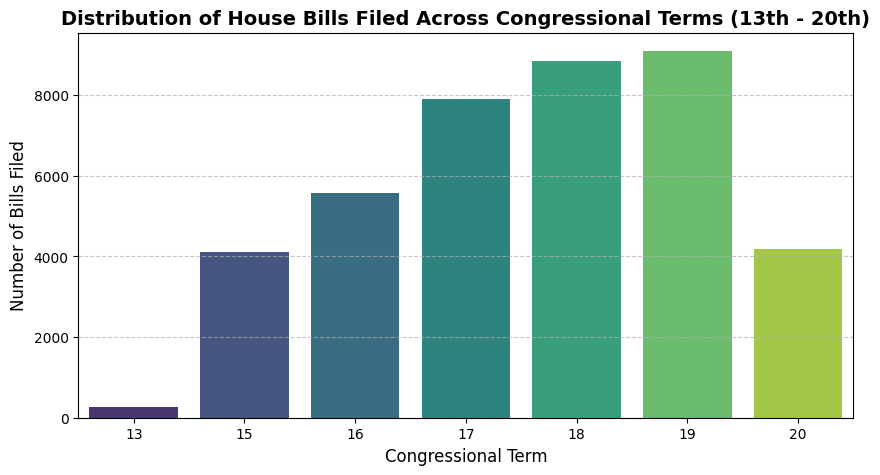

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Count bills per congress term
sns.countplot(data=enriched_bills_with_text, x='congress', palette='viridis')

plt.title('Distribution of House Bills Filed Across Congressional Terms (13th - 20th)', fontsize=14, fontweight='bold')
plt.xlabel('Congressional Term', fontsize=12)
plt.ylabel('Number of Bills Filed', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This next analysis checks which months have the most bills filed. Surprisingly, it is aroung July where it peaks, then immediately descends on the following months. The months except for July do have a relatively similar date filed.

C:\Users\user\AppData\Local\Temp\ipykernel_26332\881279771.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=enriched_bills_with_text, x='month_name', order=month_order, palette='plasma')


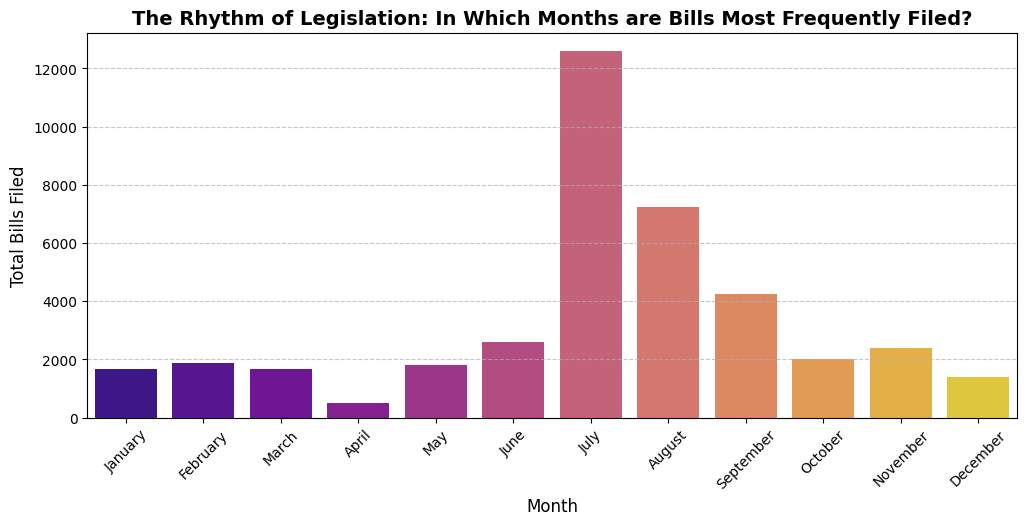

In [45]:
# Convert date column to datetime safely
enriched_bills_with_text['date_filed'] = pd.to_datetime(enriched_bills_with_text['date_filed'], errors='coerce')

# Extract month names
enriched_bills_with_text['month_name'] = enriched_bills_with_text['date_filed'].dt.strftime('%B')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 5))
# Plot monthly frequency
sns.countplot(data=enriched_bills_with_text, x='month_name', order=month_order, palette='plasma')

plt.title('The Rhythm of Legislation: In Which Months are Bills Most Frequently Filed?', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Bills Filed', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This next visualization introduces the most hyper-active lawmakers. Because authors_list is a comma-separated string, we can split it, count individual appearances, and find out who the top 10 most frequent authors are. Leading the list is Rufus Bautista Rodriguez, followed by Luis Raymund Villafuerte, and finishing the podium is Alfred Vargas III.

C:\Users\user\AppData\Local\Temp\ipykernel_26332\1784985765.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=auth_df, x='Bill Count', y='Author', palette='magma')


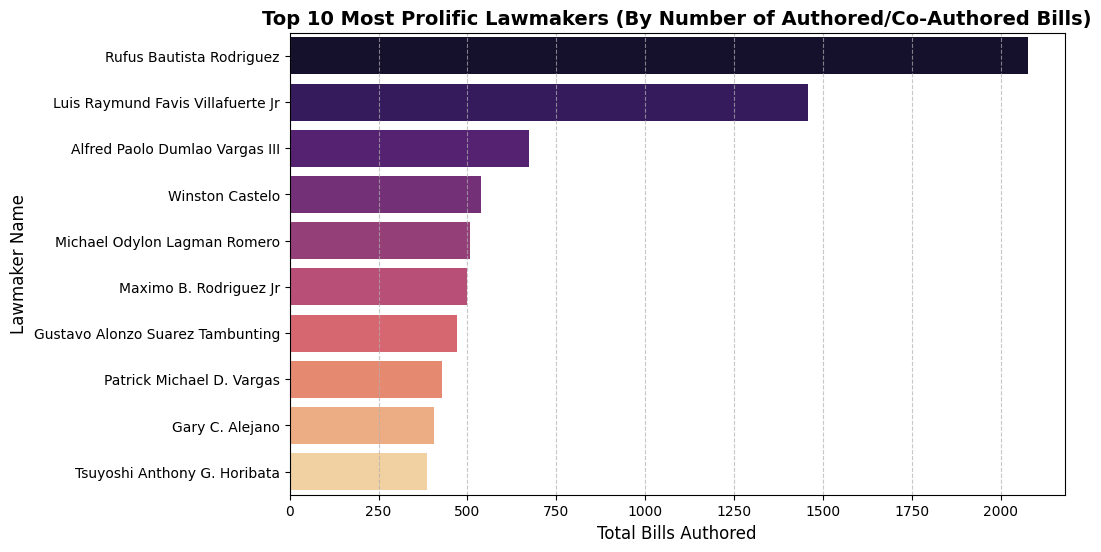

In [ ]:
from collections import Counter

all_authors = []
for authors in enriched_bills_with_text['authors_list'].dropna():
    all_authors.extend([auth.strip() for auth in authors.split(',') if auth.strip()])

# Get the top 10 most common authors
top_authors = Counter(all_authors).most_common(10)
auth_df = pd.DataFrame(top_authors, columns=['Author', 'Bill Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=auth_df, x='Bill Count', y='Author', palette='magma')

plt.title('Top 10 Most Prolific Lawmakers (By Number of Authored/Co-Authored Bills)', fontsize=14, fontweight='bold')
plt.xlabel('Total Bills Authored', fontsize=12)
plt.ylabel('Lawmaker Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [47]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


This next visualization uses the wordcloud library. Before doing deep AI summaries, we can look at the congress_website_title column to see which topics dominate our history (e.g., "Health", "Education", "Taxation"). Stopwords area also introduced to filter out common words, and will help in identifying themes.

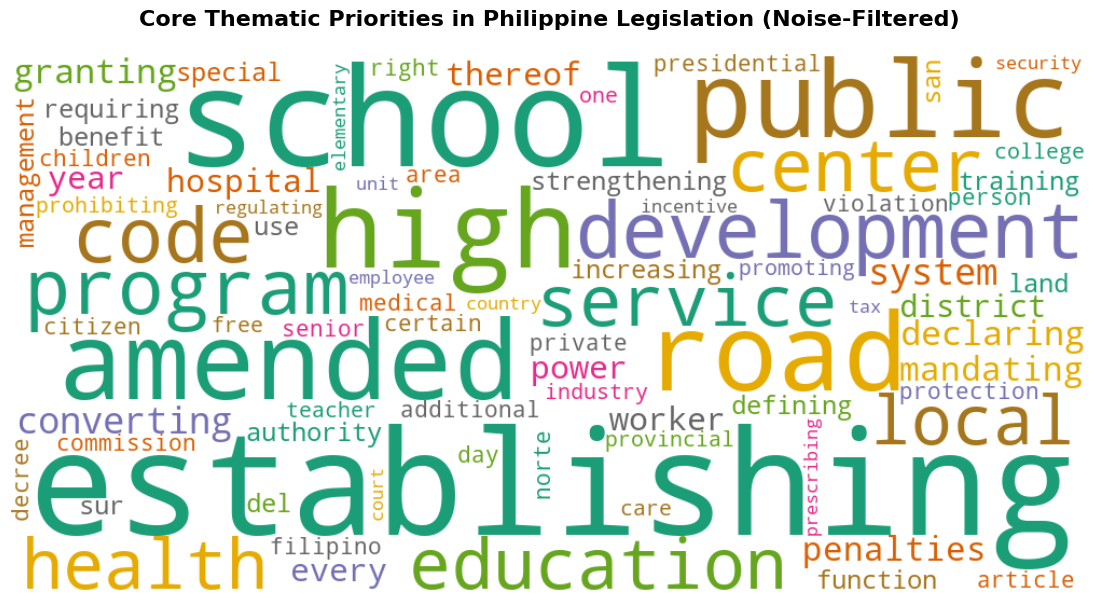

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = set(STOPWORDS)

legislative_noise = {
    'act', 'creating', 'province', 'municipality', 'barangay', 'city', 'national', 
    'appropriating', 'funds', 'therefor', 'purpose', 'purposes', 'amending', 
    'section', 'sections', 'republic', 'hereby', 'converted', 'known', 'said',
    'provinces', 'cities', 'municipalities', 'barangays', 'establishment', 
    'established', 'house', 'bill', 'senate', 'laws', 'law', 'state', 'government',
    'office', 'officer', 'offices', 'department', 'departments', 'board', 'council',
    'philippines', 'philippine', 'region', 'institutionalizing', 'providing', 'provide'
}
custom_stopwords.update(legislative_noise)

all_titles_text = " ".join(enriched_bills_with_text['congress_website_title'].dropna().astype(str)).lower()

wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    max_words=80,
    stopwords=custom_stopwords,
    collocations=False,
    colormap='Dark2',       # Using a highly contrasting, clean palette
    random_state=42
).generate(all_titles_text)

# 5. Render the final thematic visualization
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') 

plt.title('Core Thematic Priorities in Philippine Legislation (Noise-Filtered)', fontsize=16, fontweight='bold', pad=20)
plt.show()

As you can see, there is an abundance in education, road development, and health, while there are some words regarding penalties, violations, power, tax, which suggest other themes that are not as dominant

## **Natural Language Processing (NLP) & Inference Evaluation Pipeline**

This chapter details the deployment of a localized, privacy-focused Large Language Model (LLM) engine designed to perform automated analysis on Philippine legislative bills. The entire architecture is run locally. The pipeline incorporates a generation component alongside a mathematical validation framework utilizing lexical overlap verification ($ROUGE$).

### Local Model Asset Serialization


Before executing offline inference, the model weights and tokenization configurations must be fetched from the Hugging Face Hub and serialized to local storage. This step downloads the **Qwen2.5-0.5B-Instruct** architecture. This model is an optimized, sub-billion parameter model commonly used for high-density text analysis on local hardware.
- **AutoModelForCausalLM**: This is an architectural class loader for autoregressive language models that handle text generation tasks.

In [39]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
save_directory = "./qwen_local_model"

print(f"Downloading and saving {model_name} to '{save_directory}'...")

# Download and save the weights and configuration
model = AutoModelForCausalLM.from_pretrained(model_name)
model.save_pretrained(save_directory)

# Download and save the tokenizer settings (crucial for chat templates)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.save_pretrained(save_directory)

print("Model and Tokenizer successfully saved locally!")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer successfully saved locally!


### Offline Pipeline Instantiation (BEGIN HERE IF THE MODEL IS MADE)


Once the assets are compiled locally, the inference execution framework is constructed. This cell ingests the clean dataset and model to fully function offline.

In [40]:
import pandas as pd
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
cleaned_bills_df = pd.read_csv("enriched_bills_with_text.csv")

local_path = "./qwen_local_model"
print(f"Loading generation engine directly from local storage: {local_path}...")

local_model = AutoModelForCausalLM.from_pretrained(local_path)
local_tokenizer = AutoTokenizer.from_pretrained(local_path)

local_generator = pipeline(
    "text-generation", 
    model=local_model,
    tokenizer=local_tokenizer
)

print("Local pipeline ready for offline inference!")

Loading generation engine directly from local storage: ./qwen_local_model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Local pipeline ready for offline inference!


### Prompt Engineering & Structural Analysis


To transform raw legislative House Bills into civic summaries, we construct a structured prompt template. The prompt forces the LLM to output a dedicated analysis containing three explicit pillars: **Overview, Core Objectives, and Citizen Impact**.

Important Hyperparameters:
- **apply_chat_template()**: Dynamically injects special tokens (e.g., <|im_start|>, <|im_end|>) required by Qwen to differentiate instructions from input data.
- **temperature**=0.4: Configures the token distribution curve to prioritize deterministic factual text while retaining semantic fluency.

In [51]:
def generate_bill_analysis_local_detailed(title, content):
    if not content or str(content).strip() == "":
        return "No content available to analyze."
        
    truncated_content = str(content)[:2500]
    
    messages = [
        {
            "role": "system", 
            "content": (
                "You are a precise legislative assistant. Provide an objective, highly concise breakdown. "
                "Keep descriptions short, direct, and dense. Avoid conversational filler or repeating background data."
            )
        },
        {
            "role": "user", 
            "content": f"""Analyze this Philippine House Bill. Keep each section to 1-2 concise bullet points or short sentences maximum.

### Overview: Brief context of the bill.
### Core Objectives: Main goals/changes enforced.
### Citizen Impact: Why this matters to citizens.

Bill Title: {title}
Bill Content:
{truncated_content}

Detailed Analysis:"""}
    ]
    
    prompt = local_generator.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    try:
        eos_token = local_generator.tokenizer.eos_token if local_generator.tokenizer.eos_token else "<|im_end|>"
        
        outputs = local_generator(
            prompt, 
            max_new_tokens=400,    # Slightly tightened ceiling
            max_length=None,       # Suppresses the warning flag
            temperature=0.2,       # Lower temperature makes it more factual and concise
            do_sample=True,
            repetition_penalty=1.2, # NEW: Explicitly stops the model from looping or rambling
            pad_token_id=local_generator.tokenizer.eos_token_id,
            tokenizer=local_generator.tokenizer, 
            stop_strings=[eos_token, "<|im_end|>"]
        )
                
        generated_text = outputs[0]['generated_text']
        clean_summary = generated_text.split("<|im_start|>assistant\n")[-1].strip()
        
        if clean_summary.endswith(eos_token):
            clean_summary = clean_summary[:-len(eos_token)].strip()
            
        return clean_summary
        
    except Exception as e:
        return f"Error running local model analysis: {e}"

This is a sample output:

In [49]:
sample_title = cleaned_bills_df['congress_website_title'].iloc[0]
sample_content = cleaned_bills_df['content'].iloc[0]

print("\nTesting Local Hybrid Analysis Engine:")
print("-" * 60)
print(generate_bill_analysis_local_detailed(sample_title, sample_content))
print("-" * 60)

[transformers] Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Testing Local Hybrid Analysis Engine:
------------------------------------------------------------
### Overview:

#### Issue and Background Context:

The Philippine Labor Code (P.L. 6727) was enacted in 1989 with the aim of rationalizing wage policy determination by establishing mechanisms and proper standards. This bill aims to reform the current wage system, ensuring fair compensation for workers while maintaining economic stability. The core objectives of this bill include:

1. **Establishing Mechanisms**: To create a transparent and fair system for determining wages based on market rates.
2. **Proper Standards**: Ensuring that wages reflect the true cost of living and are commensurate with the value of labor.
3. **Wage Incentives**: Providing incentives for industries to disperse jobs across different regions to enhance economic growth.
4. **Other Provisions**: Including provisions related to unemployment benefits, social security, and other essential services.

#### Citizen Impac

### Batch Evaluation Metric Engine


To measure model performance mathematically, we implement an automated validation loop. The generation accuracy is evaluated via the **Compression Ratio** and the **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)** framework, which tests keyword retention against the character input chunk processed by the system.

A sample size of 5 is used to evaluate, as the LLM generation will take a long time. This sample batch is used as a baseline level in terms of the performance of the model.

- **Compression Ratio (Length of summary/Length of original input)**
- **ROUGE Overlap (Self-Coverage evaluation)** - Measures the recall, how many core words were from the original source and successfully persisted inside the generated text

In [52]:

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def evaluate_summary_metrics(original_text, generated_summary):
    """
    Computes mathematical and textual metrics comparing the raw bill text
    with the model's generated analytical output.
    """
    if "Error" in generated_summary or len(generated_summary) < 10:
        return 0.0, 0.0, 0.0
        
    compression_ratio = len(generated_summary) / len(str(original_text))

    scores = scorer.score(str(original_text), generated_summary)
    rouge1_recall = scores['rouge1'].recall
    rougel_recall = scores['rougeL'].recall
    
    return round(compression_ratio, 3), round(rouge1_recall, 3), round(rougel_recall, 3)


sample_size = 5
metric_subset_df = cleaned_bills_df.head(sample_size).copy()

print(f"Running Local Generation & Metric Audit on {sample_size} records...")

summaries, comp_ratios, r1_recalls, rl_recalls = [], [], [], []

for index, row in metric_subset_df.iterrows():
    input_text_chunk = str(row['content'])[:2500]
    
    analysis = generate_bill_analysis_local_detailed(row['congress_website_title'], row['content'])
    summaries.append(analysis)
    
    comp, r1, rl = evaluate_summary_metrics(input_text_chunk, analysis)
    comp_ratios.append(comp)
    r1_recalls.append(r1)
    rl_recalls.append(rl)
    
    print(f"Metrics Tracked for Bill {index+1} | Compression Ratio: {comp*100:.1f}% | Context Recall: {r1*100:.1f}%")

metric_subset_df["generated_analysis"] = summaries
metric_subset_df["metric_compression_ratio"] = comp_ratios
metric_subset_df["metric_rouge1_recall"] = r1_recalls
metric_subset_df["metric_rougel_recall"] = rl_recalls

print("\nPERFORMANCE METRICS EVALUATION PASS COMPLETE!")
metric_subset_df[["name", "metric_compression_ratio", "metric_rouge1_recall", "metric_rougel_recall"]].head()

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'stop_strings', 'max_new_tokens', 'do_sample', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Local Generation & Metric Audit on 5 records...


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Metrics Tracked for Bill 1 | Compression Ratio: 66.1% | Context Recall: 16.0%


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Metrics Tracked for Bill 3 | Compression Ratio: 75.6% | Context Recall: 27.4%


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Metrics Tracked for Bill 4 | Compression Ratio: 33.0% | Context Recall: 9.2%
Metrics Tracked for Bill 5 | Compression Ratio: 40.0% | Context Recall: 14.3%

PERFORMANCE METRICS EVALUATION PASS COMPLETE!


,name,metric_compression_ratio,metric_rouge1_recall,metric_rougel_recall
0,HBN-04293,0.661,0.160,0.081
1,HBN-04303,0.496,0.140,0.074
2,HBN-04250,0.756,0.274,0.145
3,HBN-04251,0.330,0.092,0.057
4,HBN-04252,0.400,0.143,0.071


### Statistical Visualization


The final component uses descriptive analytics to track the process. This block of code plots the distribution curves for text compression ratios and vocabulary retention metrics to visually identify pipeline performance anomalies.

Global Pipeline Performance Benchmarks:
Average Text Compression Ratio: 52.86%
Average Core Keyword Recall (ROUGE-1): 16.18%


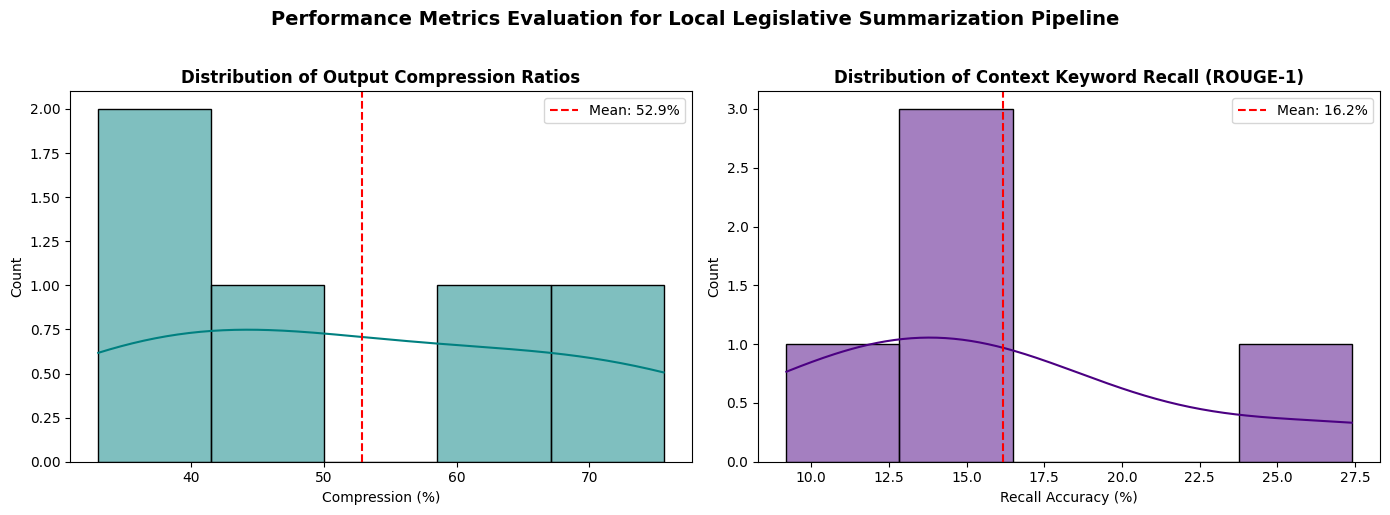

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_compression = metric_subset_df['metric_compression_ratio'].mean() * 100
avg_recall = metric_subset_df['metric_rouge1_recall'].mean() * 100

print("Global Pipeline Performance Benchmarks:")
print(f"Average Text Compression Ratio: {avg_compression:.2f}%")
print(f"Average Core Keyword Recall (ROUGE-1): {avg_recall:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(metric_subset_df['metric_compression_ratio'] * 100, kde=True, ax=axes[0], color='teal', bins=5)
axes[0].axvline(avg_compression, color='red', linestyle='--', label=f'Mean: {avg_compression:.1f}%')
axes[0].set_title('Distribution of Output Compression Ratios', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Compression (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.histplot(metric_subset_df['metric_rouge1_recall'] * 100, kde=True, ax=axes[1], color='indigo', bins=5)
axes[1].axvline(avg_recall, color='red', linestyle='--', label=f'Mean: {avg_recall:.1f}%')
axes[1].set_title('Distribution of Context Keyword Recall (ROUGE-1)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall Accuracy (%)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Performance Metrics Evaluation for Local Legislative Summarization Pipeline', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Analysis

**Output Compression**
- Because we asked the model to write a highly comprehensive analysis broken down into three distinct sections **(Overview, Core Objectives, and Citizen Impact)**, a compression ratio in the 50% range is generally okay. It shows that the model is condensed enough to filter out raw legal clutter, but verbose enough to maintain the structural formatting and rich explanatory content. 


**ROUGE-1**
- For generative or abstractive language models, a ROUGE-1 recall rate around 15% is generally poor. It does capture some instances where the local Qwen model pulls key diagnostic topics (like exact policy names, affected civic sectors, or specific economic conditions) directly from the source text, rather than hallucinating or drifting into generic filler phrases. However, this still indicates poor keyword overlap and significant loss of important information. 

However, due to the dense text of the House Bills, this ROUGE-1 recall result might be an indication that the model did not capture random words that cluttered the House Bills. That is something to be considered as well. This goes the same for Output Compression. Additionally, it is important to take note that 5 samples were only used for this evaluation.

## Conclusion

This project successfully demonstrates the deployment of a localized, high-efficiency data pipeline designed to ingest, serialize, and analyze structural Philippine legislative documents (House Bills). The system establishes a secure, cost-effective blueprint by using a locally initialized model for processing sensitive or large-scale civic data locally.
- The integration of a localized sub-billion parameter model (Qwen2.5-0.5B-Instruct) paired with custom prompt engineering proved that compact, consumer-grade hardware can perform semantic extractions. Though the evaluation was not high for compressing dense legislative text, it was still able to summarize in an understandable manner.
- Ultimately, this research is able to bridge the gap between complex legal data and public accessibility, showing that localized artificial intelligence can successfully transform unorganized public records into clear, actionable civic summaries.

While this implementation focused on a specific validation subset of House Bills, the underlying data pipeline can serve as the groundworks for a comprehensive, production-grade search and tracking web application for both the House of Representatives and the Senate of the Philippines.
- Plaintext (Raw Documents)
- Localized Preprocessing Engine
- Local LLM / Summarizer
- Structured Vector Database
- Public Web Interface

By expanding the ingestion layer to process diverse legal document types to include Senate Bills, Republic Acts, Committee Reports, and Explanatory Notes, this pipeline can feed a centralized, two-sided web portal. Organizers, researchers, public citizens, and my target audience, the Filipino youth, could instantly access breakdowns of any active legislation.

Future iterations of this project will focus on upgrading the local engine to more robust, high-capacity models. While the $0.5B$ parameter model provides exceptional speed and ultra-low memory requirements, moving toward larger local architectures will significantly boost the pipeline's analytical depth. Larger models possess broader internal vocabulary maps and superior cross-referencing capabilities. This upgrade will allow the pipeline to:
- Handle longer context windows.
- Identify loopholes and provisions, and historical policy precedents across multiple bills.
- Improve $ROUGE$ accuracy and lower temperature variance, yielding highly nuanced summaries that read like professional legal briefs.